In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.cluster import KMeans

In [6]:
class PaperImplementation:
    def __init__(self, sp=15, sr=30):
        """
        sp: Spatial Window Radius (h_d pada jurnal)
        sr: Color Window Radius (h_r pada jurnal)
        """
        self.sp = sp
        self.sr = sr

    def run_process(self, image_path):
        # 1. Load Image
        img = cv2.imread(image_path)
        if img is None:
            print("Error: Gambar tidak ditemukan.")
            return
        
        # Resize agar proses tidak terlalu berat (Mean Shift komputasinya mahal)
        # Jurnal menggunakan bandwidth h_d=5, h_r=0.1-0.2 (skala 0-1) atau setara pixel
        scale_percent = 50 
        width = int(img.shape[1] * scale_percent / 100)
        height = int(img.shape[0] * scale_percent / 100)
        dim = (width, height)
        img = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
        
        # Konversi BGR (OpenCV) ke RGB (untuk Matplotlib)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- TAHAP 1: Spatial-Range Mean Shift Filtering [cite: 32, 43] ---
        # Ini menghasilkan F(s) - gambar yang sudah di-smoothing
        print("Menjalankan Mean Shift Filtering...")
        filtered_img = cv2.pyrMeanShiftFiltering(img, self.sp, self.sr)
        filtered_rgb = cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB)

        # --- TAHAP 2: Membuat Convergence Map M(s) [cite: 33, 75] ---
        # Jurnal: M(s)=0 (Putih) di edges, M(s) tinggi (Hitam) di area homogen[cite: 72].
        # Karena cv2.pyrMeanShift tidak mengembalikan hit count per pixel, 
        # kita aproksimasi M(s) menggunakan invers dari gradient magnitude.
        # Area flat = gradient rendah = konvergensi tinggi (Hitam).
        # Area edge = gradient tinggi = konvergensi rendah (Putih).
        
        gray_filtered = cv2.cvtColor(filtered_img, cv2.COLOR_BGR2GRAY)
        grad_x = cv2.Sobel(gray_filtered, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray_filtered, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        
        # Normalisasi ke 0-255
        gradient_norm = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # Jurnal[cite: 72]: "white: indicate edges, black: indicate nearer to edges"
        # Jadi M(s) visualnya harus Putih di Edge. Gradient tinggi = Edge = Putih.
        # Maka M_visual adalah gradient itu sendiri.
        M_visual = gradient_norm 

        # --- TAHAP 3: Pre-Segmentation [cite: 34, 131] ---
        # Mengelompokkan warna yang mirip (over-segmentation)
        # Kita gunakan connected components pada hasil filter
        # Untuk visualisasi agar terlihat seperti "patchy" color segments di jurnal
        # kita bisa langsung menggunakan filtered_rgb karena Mean Shift sudah melakukan quantization.
        pre_segmentation = filtered_rgb

        # --- TAHAP 4: Refined Segmentation [cite: 35, 135] ---
        # Menggabungkan region kecil berdasarkan M(s).
        # Di sini kita simulasikan visualisasinya dengan menggambar boundary 
        # di atas gambar hasil filter.
        
        # Deteksi edge dari label segmentasi
        edges = cv2.Canny(filtered_img, 100, 200)
        
        # Buat overlay boundary
        refined_seg = filtered_rgb.copy()
        # Warnai boundary dengan warna putih/terang agar mirip Fig 2 baris 4
        refined_seg[edges > 0] = [255, 255, 255] 

        # --- PLOTTING SEPERTI FIG. 2  ---
        self.plot_fig2_style(img_rgb, M_visual, pre_segmentation, refined_seg)

    def plot_fig2_style(self, original, m_map, pre_seg, refined):
        # Setup plot: 1 baris, 4 kolom
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # 1. Original Image
        axes[0].imshow(original)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # 2. Convergence Map M(s)
        # Gunakan cmap='gray_r' (reverse) atau 'gray' tergantung interpretasi.
        # Jurnal Fig 1: Edge berwarna PUTIH, area rata berwarna ABU/HITAM.
        axes[1].imshow(m_map, cmap='gray') 
        axes[1].set_title("Map M(s)\n(White=Edge)")
        axes[1].axis('off')
        
        # 3. Pre-Segmentation Results
        axes[2].imshow(pre_seg)
        axes[2].set_title("Pre-Segmentation")
        axes[2].axis('off')
        
        # 4. Refined Segmentation Results
        axes[3].imshow(refined)
        axes[3].set_title("Refined Segmentation")
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()

Menjalankan Mean Shift Filtering...


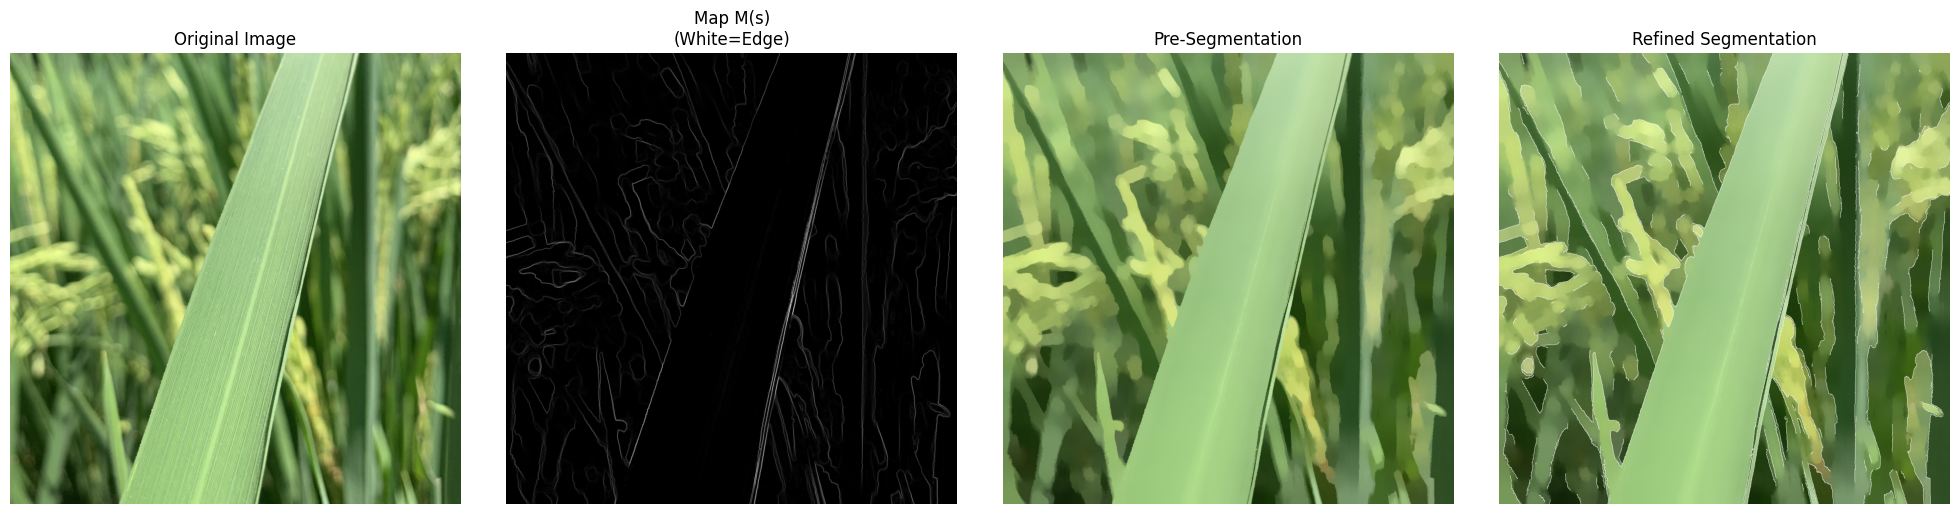

In [7]:
# --- EKSEKUSI ---
# Ganti 'peppers.png' dengan nama file gambar Anda yang sebenarnya
processor = PaperImplementation(sp=20, sr=40)
processor.run_process('D:/Backup Mario/Coding Room/Rice_Disease/datasets/result/260127 2355 Mixed On Field No Duplicate Normal No Indo/test_images2/normal/IMG_5307 - Copy.JPG') # Pastikan path file benar

Menerapkan Mean Shift Filtering...


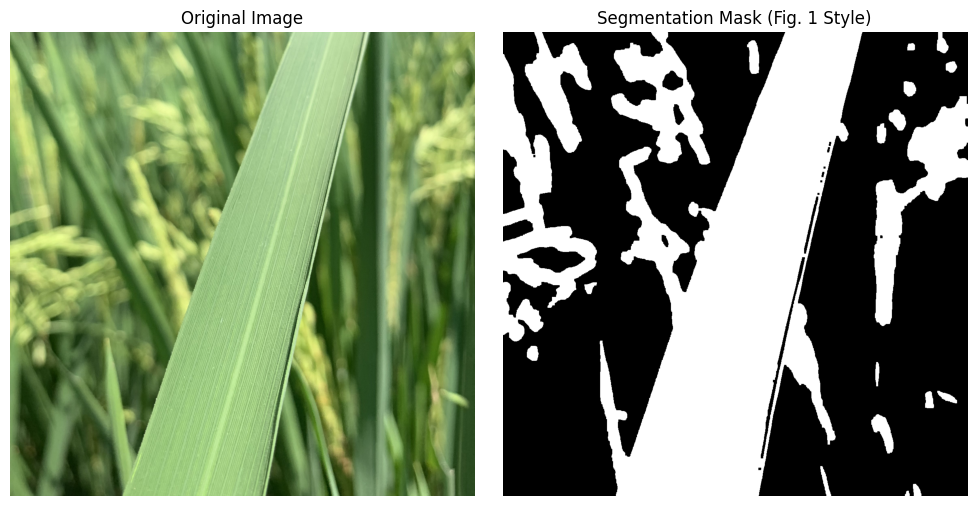

In [9]:
def rice_disease_segmentation(image_path):
    # 1. Load Image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Gambar tidak ditemukan.")
        return

    # Resize untuk mempercepat Mean Shift (opsional, tapi disarankan)
    # Jiang et al. juga menyebutkan resize ke 800x600 atau lebih kecil [cite: 313]
    h, w = img.shape[:2]
    scale_factor = 0.5
    img_resized = cv2.resize(img, (int(w * scale_factor), int(h * scale_factor)))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # --- TAHAP 1: Enhanced Spatial-Range Mean Shift (Song et al.) ---
    # Ini adalah inti metode jurnal pertama.
    # Mengurangi noise dan membuat warna "flat" (homogen) pada area daun dan lesi.
    # sp: spatial window radius, sr: color window radius
    print("Menerapkan Mean Shift Filtering...")
    shifted = cv2.pyrMeanShiftFiltering(img_resized, sp=20, sr=40)
    shifted_rgb = cv2.cvtColor(shifted, cv2.COLOR_BGR2RGB)

    # --- TAHAP 2: Clustering (Jiang et al. ) ---
    # "Firstly, cluster all pixels... pixels converging to the same maximum value are classified"
    # Kita gunakan K-Means untuk mengelompokkan hasil Mean Shift menjadi 3 cluster utama:
    # 1. Background (biasanya gelap/hitam)
    # 2. Daun Sehat (Hijau)
    # 3. Lesi Penyakit (Coklat/Kuning/Putih)
    
    flat_image = shifted_rgb.reshape((-1, 3))
    flat_image = np.float32(flat_image)

    # K=3 (Background, Leaf, Lesion)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    K = 3
    ret, label, center = cv2.kmeans(flat_image, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # --- TAHAP 3: Identifikasi Cluster Lesi ---
    # Kita perlu tahu cluster mana yang merupakan "Penyakit".
    # Logika Heuristik:
    # - Background: Intensitas rata-rata paling rendah (gelap).
    # - Daun Sehat: Komponen Hijau (G) dominan dan saturasi sedang.
    # - Penyakit: Cluster tersisa (bisa coklat, kuning, atau putih).

    center = np.uint8(center)
    lesion_cluster_index = -1
    
    # Analisis setiap center cluster
    min_green_dominance = 999
    
    for i in range(K):
        c = center[i] # [R, G, B]
        # Konversi ke HSV untuk analisis warna yang lebih baik
        hsv_c = cv2.cvtColor(np.uint8([[c]]), cv2.COLOR_RGB2HSV)[0][0]
        
        # Deteksi Background (Sangat gelap)
        if hsv_c[2] < 40: 
            continue # Ini background
            
        # Deteksi Daun Sehat (Dominan Hijau)
        # Hue Hijau sekitar 35 - 85
        if 35 < hsv_c[0] < 85:
            continue # Ini daun sehat
            
        # Jika bukan background dan bukan daun sehat (hijau), kemungkinan besar ini lesi
        lesion_cluster_index = i

    # Fallback: Jika logika di atas gagal (misal background tidak hitam),
    # cari cluster yang memiliki warna "paling tidak hijau".
    if lesion_cluster_index == -1:
        # Cari cluster dengan nilai Merah tertinggi (karena lesi biasanya coklat/merah)
        lesion_cluster_index = np.argmax(center[:, 0]) 

    # --- TAHAP 4: Membuat Binary Mask (Fig. 1 Jiang et al.) ---
    # Buat mask hanya untuk cluster lesi
    mask = (label.flatten() == lesion_cluster_index).reshape(shifted_rgb.shape[:2])
    
    # Post-processing morfologi untuk membersihkan noise (remove small dots)
    # Sesuai [cite: 311] "remove background noise"
    binary_img = (mask * 255).astype(np.uint8)
    kernel = np.ones((3,3), np.uint8)
    binary_img = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel, iterations=2)
    binary_img = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=2)

    # --- VISUALISASI SEPERTI FIG. 1 JURNAL JIANG ET AL. ---
    plt.figure(figsize=(10, 5))

    # Gambar Asli (Crop contoh dari jurnal)
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    # Gambar Biner (Segmentation Result)
    plt.subplot(1, 2, 2)
    plt.imshow(binary_img, cmap='gray')
    plt.title("Segmentation Mask (Fig. 1 Style)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Jalankan fungsi
rice_disease_segmentation('D:/Backup Mario/Coding Room/Rice_Disease/datasets/result/260127 2355 Mixed On Field No Duplicate Normal No Indo/test_images2/normal/IMG_5307 - Copy.JPG')